# NDBC 44013 – Wave Power and Cumulative Autocorrelation

**Station:** NDBC 44013 – Boston, MA (~42.346°N, 70.651°W, ~62 m depth)  
**Period:** 2024-10-01 to 2025-03-30  
**Survey dates:** 2024-10-23, 2025-01-23, 2025-03-06

### Wave power (deep-water energy flux per unit crest width)
$$P = \frac{\rho g^2}{64\pi}\, H_s^2\, T_e \quad [\text{W/m}], \qquad T_e = T_p / 1.05$$

where $\rho = 1025$ kg/m³, $g = 9.81$ m/s².  
Reference: e.g. Cornish (1910); standard deep-water group speed formulation.

### Cumulative autocorrelation – morphodynamic stability index
For each survey date $t_0$, we compute a **running (cumulative) autocorrelation** of wave power $P(t)$  
both forward and backward in time. The idea is that beach morphology at $t_0$ reflects the  
integrated forcing history, so periods where $P$ is highly self-correlated (stationary forcing)  
imply a beach system near equilibrium, while rapidly decorrelating periods imply transient  
conditions prone to morphological change.

For a lag-1 running Pearson correlation of a window growing from $t_0$:
$$r(t_0, \tau) = \text{corr}\bigl[P(t_0 \pm 1 : \tau),\; P(t_0 \pm 2 : \tau+1)\bigr]$$

Alternatively (implemented here), we compute the Pearson autocorrelation of the  
cumulative window $P[t_0 \to t_0 \pm \Delta t]$ at unit lag, growing the window by one  
timestep at a time. A high value near 1 means the record up to that point has been  
stationary/persistent; a value near 0 or negative means the record has been episodic.

**Reference for morphodynamic equilibrium concept:**  
Wright, L.D., Short, A.D., 1984. Morphodynamic variability of surf zones and beaches.  
*Marine Geology*, 56, 93–118. https://doi.org/10.1016/0025-3227(84)90008-2

Splinter, K.D., Turner, I.L., Davidson, M.A., Barnard, P., Castelle, B., Oltman-Shay, J., 2014.  
A generalized equilibrium model for predicting daily to interannual shoreline response.  
*JGR Earth Surface*, 119, 1936–1958. https://doi.org/10.1002/2014JF003106

In [1]:
# csherwood@usgs.gov, 2025-06-25, generated with Claude Sonnet 4.6

import numpy as np
import pandas as pd
import requests
import io
import gzip
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import pearsonr

# ── Config ────────────────────────────────────────────────────────────────────
STATION      = '44013'
T_START      = '2024-10-01'
T_END        = '2025-03-30'
SURVEY_DATES = pd.to_datetime(['2024-10-23', '2025-01-23', '2025-03-06'])
CACHE_DIR    = './ndbc'
SMOOTH_H     = 24   # smoothing window for wave power before autocorrelation (hours); 1 = no smoothing
os.makedirs(CACHE_DIR, exist_ok=True)

# Physical constants
rho = 1025.0   # kg/m³
g   = 9.81     # m/s²
COEFF = rho * g**2 / (64 * np.pi)  # W·s/m³

SMOOTH_H = 6

In [2]:
# ── Download / cache NDBC stdmet data ────────────────────────────────────────
# NDBC serves historical data as annual .txt.gz; recent data (current year)
# comes from the 'stdmet' real-time or 'realtime2' path.
# We need parts of 2024 and 2025.

def fetch_ndbc_year(station, year, cache_dir):
    """Download one year of NDBC stdmet data; return DataFrame or None."""
    # Historical files
    url_hist = (f'https://www.ndbc.noaa.gov/data/historical/stdmet/'
                f'{station}h{year}.txt.gz')
    # Recent (current / last year) – try stdmet continuous file
    url_recent = (f'https://www.ndbc.noaa.gov/data/stdmet/'
                  f'{station}/{station}{year}.txt.gz')

    cache_path = os.path.join(cache_dir, f'{station}_{year}.pkl')
    if os.path.exists(cache_path):
        print(f'  {year}: loaded from cache')
        return pd.read_pickle(cache_path)

    for url in [url_hist, url_recent]:
        r = requests.get(url, timeout=30)
        if r.status_code == 200:
            print(f'  {year}: downloaded from {url}')
            break
    else:
        print(f'  {year}: not found')
        return None

    with gzip.open(io.BytesIO(r.content), 'rt') as f:
        raw = f.read()

    lines = raw.splitlines()
    # Line 0: header (may start with '#'); line 1: units (also starts with '#')
    header_raw = lines[0].lstrip('#').split()
    skip = 2 if lines[1].lstrip().startswith('#') else 1

    # Give every column a clean name: strip any leading '#' from each token
    header = [h.lstrip('#') for h in header_raw]
    print(f'  {year} raw header: {header[:10]}')

    df = pd.read_csv(io.StringIO('\n'.join(lines[skip:])),
                     sep=r'\s+', header=None, names=header,
                     na_values=['99', '999', '9999', '99.0', '999.0', '9999.0'])

    # NDBC time columns by position (always columns 0-4 or 0-3):
    #   [0] YY or YYYY   [1] MM (month)  [2] DD  [3] hh (hour)  [4] mm (minute, optional)
    # Rename by position to avoid any case/# ambiguity.
    cols = list(df.columns)
    time_names = ['YYYY', 'MM', 'DD', 'hh', 'mi']   # mi = minute
    for i, name in enumerate(time_names[:min(5, len(cols))]):
        cols[i] = name
    df.columns = cols

    # Build datetime index
    has_minute = 'mi' in df.columns and df.columns.tolist().index('mi') < 5
    dt_dict = {'year': df['YYYY'], 'month': df['MM'],
               'day': df['DD'],   'hour': df['hh']}
    if has_minute:
        dt_dict['minute'] = df['mi']
    df['dt'] = pd.to_datetime(dt_dict)
    df = df.set_index('dt').sort_index()
    df.to_pickle(cache_path)
    return df

frames = []
for yr in [2024, 2025]:
    df_yr = fetch_ndbc_year(STATION, yr, CACHE_DIR)
    if df_yr is not None:
        frames.append(df_yr)

raw_all = pd.concat(frames).sort_index()
print(f'Full record: {raw_all.index[0]} → {raw_all.index[-1]}, {len(raw_all)} rows')

  2024: loaded from cache
  2025: loaded from cache
Full record: 2024-01-01 00:00:00 → 2025-12-31 23:50:00, 105212 rows


In [3]:
# ── Extract Hs, Tp; compute wave power ───────────────────────────────────────
# NDBC stdmet column names: WVHT = Hs (m), DPD = dominant period (s)

waves = raw_all.loc[T_START:T_END, ['WVHT', 'DPD']].copy()
waves.columns = ['Hs', 'Tp']
waves = waves.dropna(subset=['Hs'])   # keep rows with at least Hs

# Resample to hourly mean (NDBC is nominally hourly but can have duplicates)
waves = waves.resample('1h').mean()

# Wave energy period
waves['Te'] = waves['Tp'] / 1.05

# Deep-water wave power  P = (rho g^2 / 64pi) * Hs^2 * Te  [W/m]
waves['P_Wm'] = COEFF * waves['Hs']**2 * waves['Te']
waves['P_kWm'] = waves['P_Wm'] / 1e3

# Smooth wave power before autocorrelation
P_smooth = waves['P_kWm'].resample(f'{SMOOTH_H}h').mean()

print(waves[['Hs','Tp','P_kWm']].describe().round(2))
print(f'NaN in Hs: {waves["Hs"].isna().sum()}, '
      f'Tp: {waves["Tp"].isna().sum()}, P: {waves["P_kWm"].isna().sum()}')

            Hs       Tp    P_kWm
count  4329.00  4293.00  4293.00
mean      0.99     6.40     4.00
std       0.51     2.97     5.39
min       0.20     2.06     0.06
25%       0.60     3.85     0.90
50%       0.89     5.41     1.97
75%       1.25     8.71     4.92
max       3.45    17.39    42.77
NaN in Hs: 15, Tp: 51, P: 51


In [4]:
# ── Running cumulative autocorrelation ────────────────────────────────────────
# For each survey date, grow a window forward and backward.
# At each window length Delta_t, compute lag-1 Pearson r of the
# hourly P series within that window.
# Lag-1 autocorrelation: corr( P[0:-1], P[1:] ) on the growing window.

P = P_smooth.copy()

def running_autocorr(series, t0, direction='forward', min_pts=4):
    """
    Grow a window from t0 outward in `direction`.
    Uses positional indexing (searchsorted) so timestamp alignment
    doesn't matter. Index of returned Series is always ascending.
    """
    s = series.dropna()
    # Find the position of t0 (first index >= t0)
    i0 = s.index.searchsorted(t0)
    i0 = min(i0, len(s) - 1)
    times, rs = [], []
    if direction == 'forward':
        for n in range(min_pts, len(s) - i0 + 1):
            window = s.iloc[i0 : i0 + n].values
            r, _ = pearsonr(window[:-1], window[1:])
            times.append(s.index[i0 + n - 1])   # rightmost edge
            rs.append(r)
    else:
        for n in range(min_pts, i0 + 2):          # i0+1 points available before/at t0
            window = s.iloc[i0 + 1 - n : i0 + 1].values  # grow leftward, always end at t0
            r, _ = pearsonr(window[:-1], window[1:])
            times.append(s.index[i0 + 1 - n])   # leftmost edge (ascending)
            rs.append(r)
    return pd.Series(rs, index=times)

# Compute for each survey date, both directions
autocorr = {}
for sd in SURVEY_DATES:
    key = sd.strftime('%Y-%m-%d')
    autocorr[key] = {
        'fwd': running_autocorr(P, sd, 'forward'),
        'bwd': running_autocorr(P, sd, 'backward'),
    }
    bwd = autocorr[key]['bwd']
    fwd = autocorr[key]['fwd']
    print(f'{key}  fwd pts: {len(fwd):4d}  bwd pts: {len(bwd):4d}')
    if len(bwd):
        print(f'  bwd index range: {bwd.index[0]} → {bwd.index[-1]}')
    if len(fwd):
        print(f'  fwd index range: {fwd.index[0]} → {fwd.index[-1]}')

2024-10-23  fwd pts:  632  bwd pts:   86
  bwd index range: 2024-10-22 06:00:00 → 2024-10-01 00:00:00
  fwd index range: 2024-10-23 18:00:00 → 2025-03-30 18:00:00
2025-01-23  fwd pts:  264  bwd pts:  454
  bwd index range: 2025-01-22 06:00:00 → 2024-10-01 00:00:00
  fwd index range: 2025-01-23 18:00:00 → 2025-03-30 18:00:00
2025-03-06  fwd pts:   96  bwd pts:  622
  bwd index range: 2025-03-05 06:00:00 → 2024-10-01 00:00:00
  fwd index range: 2025-03-06 18:00:00 → 2025-03-30 18:00:00


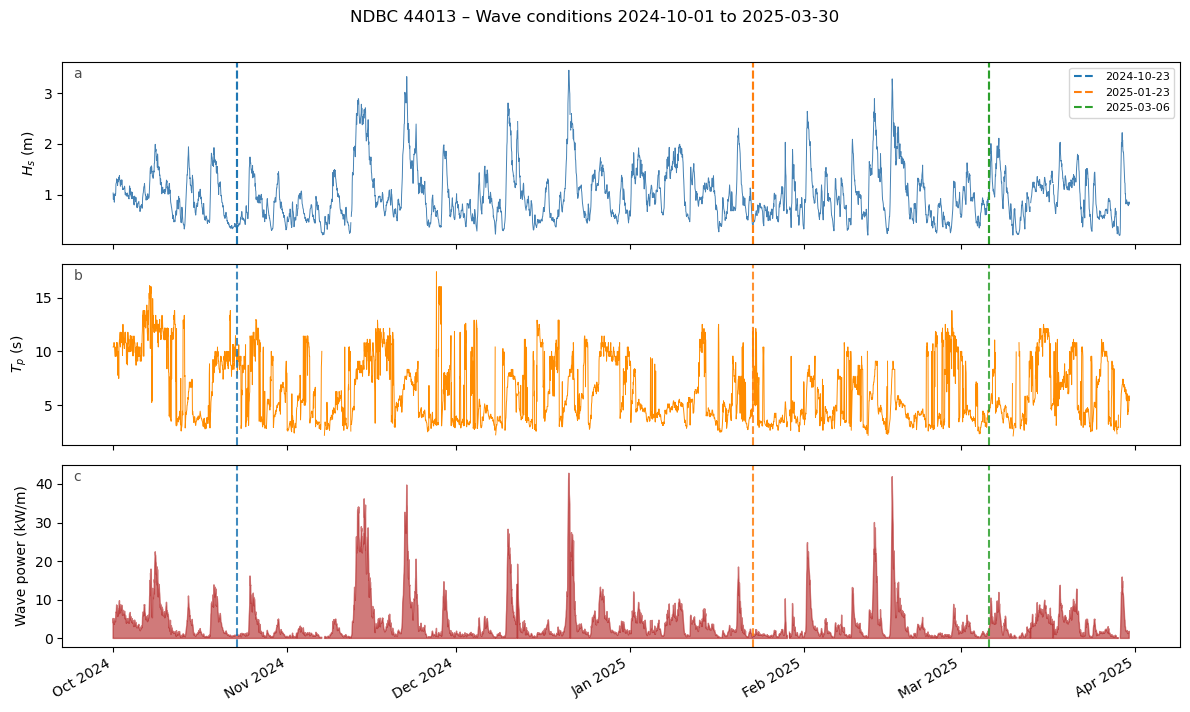

In [5]:
# ── Figure 1 – Hs, Tp, and wave power time series ────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

survey_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
panel_labels = ['a', 'b', 'c']

axes[0].plot(waves.index, waves['Hs'], lw=0.7, color='steelblue')
axes[0].set_ylabel('$H_s$ (m)')

axes[1].plot(waves.index, waves['Tp'], lw=0.7, color='darkorange')
axes[1].set_ylabel('$T_p$ (s)')

axes[2].fill_between(waves.index, waves['P_kWm'], alpha=0.6, color='firebrick')
axes[2].set_ylabel('Wave power (kW/m)')

for ax, lbl in zip(axes, panel_labels):
    for sd, sc in zip(SURVEY_DATES, survey_colors):
        ax.axvline(sd, color=sc, lw=1.5, ls='--', alpha=0.85)
    ax.text(0.01, 0.97, lbl, transform=ax.transAxes,
            va='top', ha='left', fontsize=10, color='0.3')

# Legend for survey dates on top panel
for sd, sc in zip(SURVEY_DATES, survey_colors):
    axes[0].axvline(sd, color=sc, lw=1.5, ls='--', label=sd.strftime('%Y-%m-%d'))
axes[0].legend(fontsize=8, loc='upper right')

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle(f'NDBC {STATION} – Wave conditions {T_START} to {T_END}', y=1.01)
plt.tight_layout()
plt.savefig(f'NDBC_{STATION}_wave_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

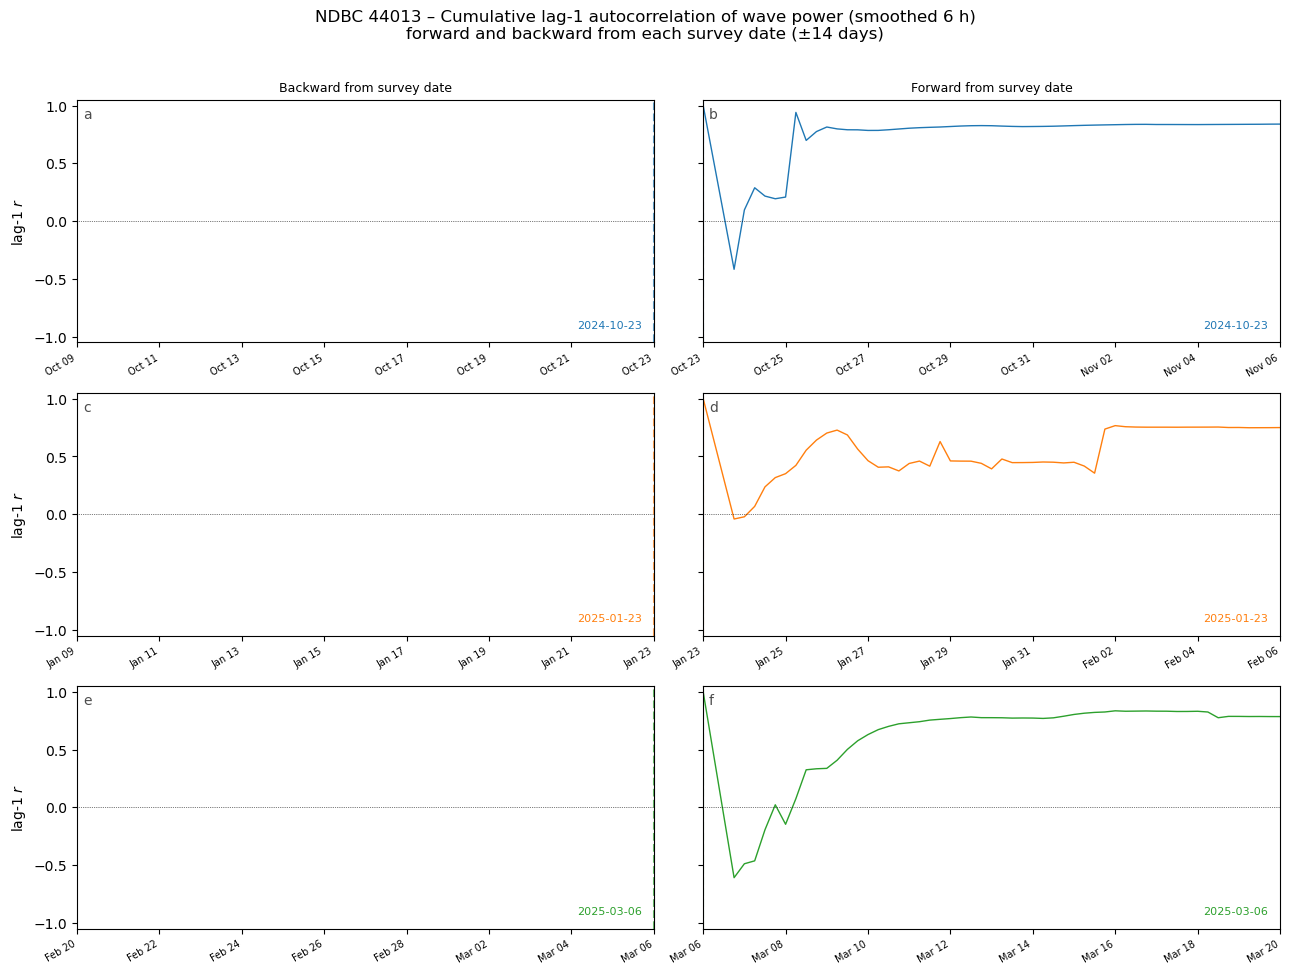

In [6]:
# ── Figure 2 – Cumulative autocorrelation around each survey date ─────────────
# One row per survey date; two columns: backward (left) and forward (right).
# r = 1 is prepended at lag 0 (the survey date itself).
# X-axis is limited to XLIM_DAYS before/after the survey date.

XLIM_DAYS = 14   # days to show on each side of survey date

n_surveys = len(SURVEY_DATES)
fig, axes = plt.subplots(n_surveys, 2,
                          figsize=(13, 3.2 * n_surveys),
                          sharey=True)

panel_idx = 0
panel_letters = [chr(ord('a') + i) for i in range(2 * n_surveys)]

for row, (sd, sc) in enumerate(zip(SURVEY_DATES, survey_colors)):
    key = sd.strftime('%Y-%m-%d')
    bwd = autocorr[key]['bwd']
    fwd = autocorr[key]['fwd']

    # Prepend r=1 at the survey date itself for both directions
    bwd = pd.concat([pd.Series([1.0], index=[sd]), bwd]).sort_index(ascending=False)
    fwd = pd.concat([pd.Series([1.0], index=[sd]), fwd]).sort_index()

    # Clip to XLIM_DAYS window
    bwd_xlim = (sd - pd.Timedelta(days=XLIM_DAYS), sd)
    fwd_xlim = (sd, sd + pd.Timedelta(days=XLIM_DAYS))
    bwd = bwd.loc[bwd_xlim[0]:bwd_xlim[1]]
    fwd = fwd.loc[fwd_xlim[0]:fwd_xlim[1]]

    for col, (s, xlim, title) in enumerate([
            (bwd, bwd_xlim, 'Backward from survey date'),
            (fwd, fwd_xlim, 'Forward from survey date')]):
        ax = axes[row, col]
        ax.plot(s.index, s.values, color=sc, lw=1.0)
        ax.axhline(0, color='k', lw=0.5, ls=':')
        ax.axvline(sd, color=sc, lw=1.5, ls='--', alpha=0.7)
        ax.set_xlim(xlim)
        ax.set_ylim(-1.05, 1.05)
        if col == 0:
            ax.set_ylabel('lag-1 $r$')
        if row == 0:
            ax.set_title(title, fontsize=9)
        ax.text(0.01, 0.97, panel_letters[panel_idx], transform=ax.transAxes,
                va='top', ha='left', fontsize=10, color='0.3')
        panel_idx += 1
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)
        ax.text(0.98, 0.05, key, transform=ax.transAxes,
                ha='right', va='bottom', fontsize=8, color=sc)

fig.suptitle(f'NDBC {STATION} – Cumulative lag-1 autocorrelation of wave power '
             f'(smoothed {SMOOTH_H} h)\nforward and backward from each survey date '
             f'(±{XLIM_DAYS} days)', y=1.01)
plt.tight_layout()
plt.savefig(f'NDBC_{STATION}_autocorr.png', dpi=150, bbox_inches='tight')
plt.show()

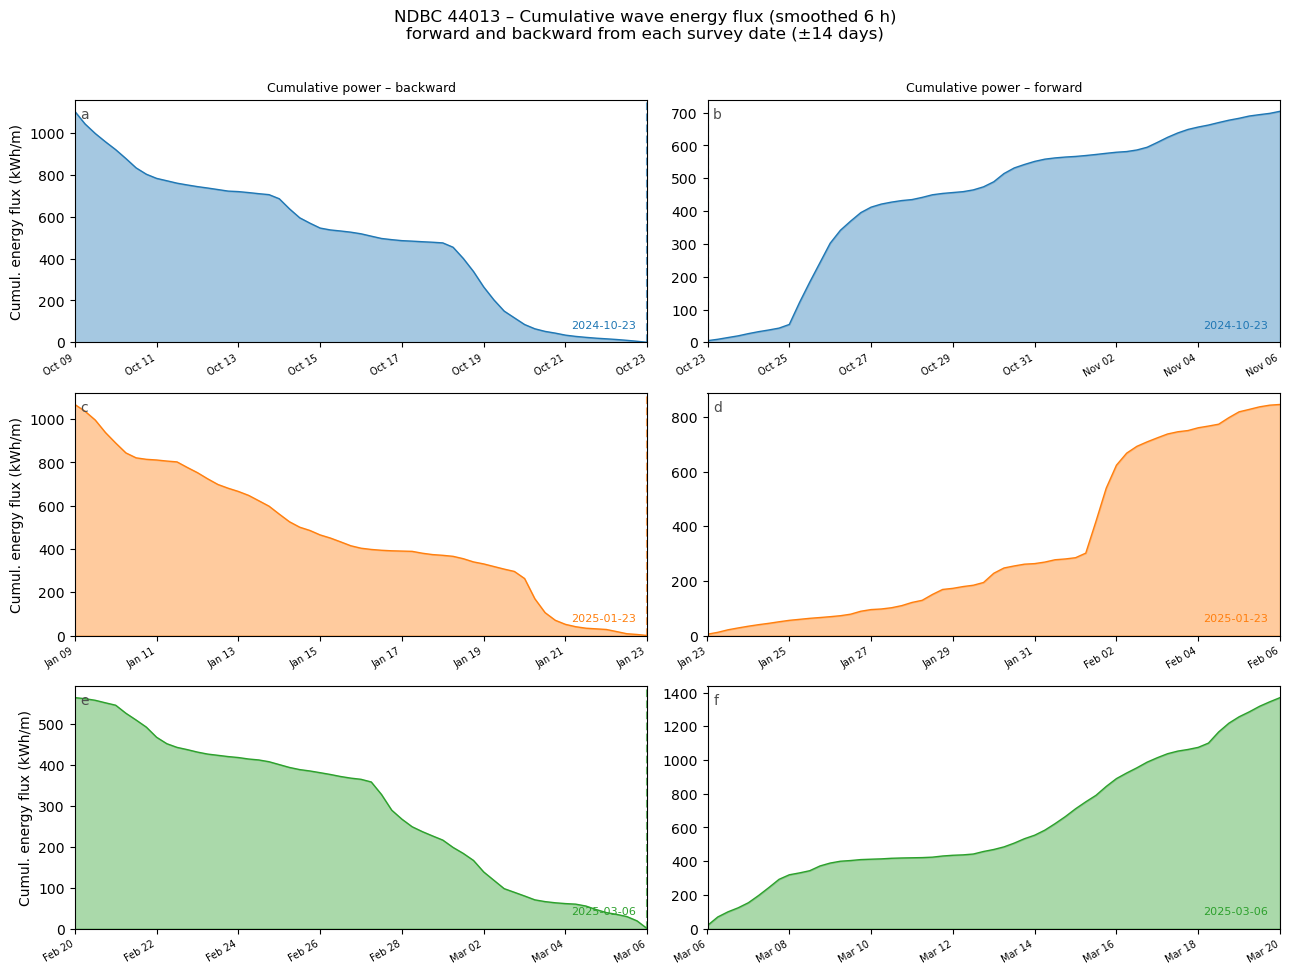

In [7]:
# ── Figure 3 – Cumulative smoothed wave power forward and backward ────────────
# For each survey date, integrate P_smooth (kW/m) × dt (h) outward in both
# directions, giving cumulative energy flux in kWh/m.
# X-axis clipped to ±XLIM_DAYS, same as autocorrelation figure.

n_surveys = len(SURVEY_DATES)
fig, axes = plt.subplots(n_surveys, 2,
                          figsize=(13, 3.2 * n_surveys),
                          sharey=False)

panel_idx = 0
panel_letters = [chr(ord('a') + i) for i in range(2 * n_surveys)]

for row, (sd, sc) in enumerate(zip(SURVEY_DATES, survey_colors)):
    key = sd.strftime('%Y-%m-%d')

    for col, (direction, xlim, title) in enumerate([
            ('bwd',
             (sd - pd.Timedelta(days=XLIM_DAYS), sd),
             'Cumulative power – backward'),
            ('fwd',
             (sd, sd + pd.Timedelta(days=XLIM_DAYS)),
             'Cumulative power – forward')]):

        if direction == 'bwd':
            seg = P_smooth.loc[xlim[0]:sd].dropna()
            # Integrate left-to-right, then reverse so x=0 is at sd
            dt_h = SMOOTH_H  # hours per sample
            cumE = np.cumsum(seg.values) * dt_h          # kWh/m, growing rightward
            cumE = cumE[-1] - cumE                        # flip: 0 at sd, grows leftward
            t = seg.index
        else:
            seg = P_smooth.loc[sd:xlim[1]].dropna()
            dt_h = SMOOTH_H
            cumE = np.cumsum(seg.values) * dt_h
            t = seg.index

        ax = axes[row, col]
        ax.fill_between(t, cumE, alpha=0.4, color=sc)
        ax.plot(t, cumE, color=sc, lw=1.0)
        ax.axvline(sd, color=sc, lw=1.5, ls='--', alpha=0.7)
        ax.set_xlim(xlim)
        ax.set_ylim(bottom=0)
        if col == 0:
            ax.set_ylabel('Cumul. energy flux (kWh/m)')
        if row == 0:
            ax.set_title(title, fontsize=9)
        ax.text(0.01, 0.97, panel_letters[panel_idx], transform=ax.transAxes,
                va='top', ha='left', fontsize=10, color='0.3')
        panel_idx += 1
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)
        ax.text(0.98, 0.05, key, transform=ax.transAxes,
                ha='right', va='bottom', fontsize=8, color=sc)

fig.suptitle(f'NDBC {STATION} – Cumulative wave energy flux (smoothed {SMOOTH_H} h)\n'
             f'forward and backward from each survey date (±{XLIM_DAYS} days)', y=1.01)
plt.tight_layout()
plt.savefig(f'NDBC_{STATION}_cumpower.png', dpi=150, bbox_inches='tight')
plt.show()

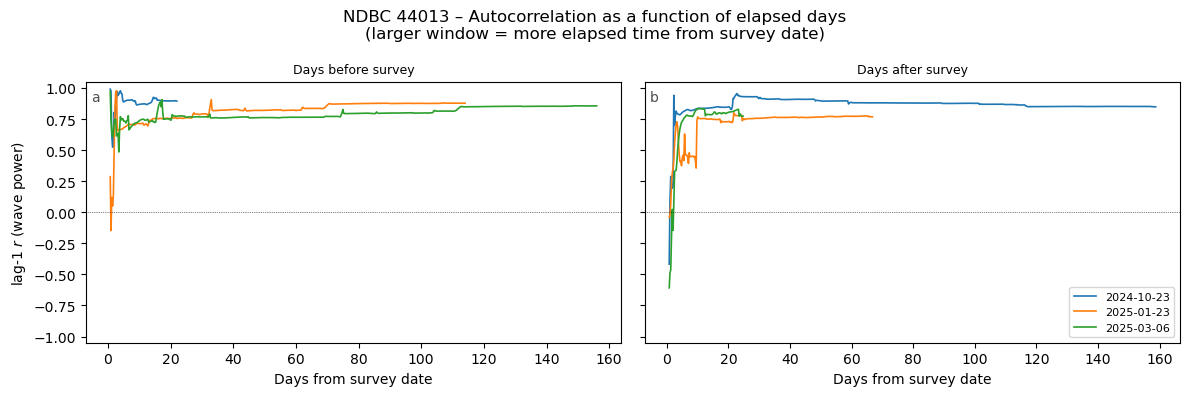

In [8]:
# ── Figure 3 – Summary: autocorr as function of days from survey date ─────────
# Re-index as offset in days so all three survey dates overlay on the same axis.

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for sd, sc in zip(SURVEY_DATES, survey_colors):
    key = sd.strftime('%Y-%m-%d')

    for col, direction in enumerate(['bwd', 'fwd']):
        s = autocorr[key][direction]
        if direction == 'bwd':
            delta_days = (sd - s.index).total_seconds() / 86400
        else:
            delta_days = (s.index - sd).total_seconds() / 86400
        axes[col].plot(delta_days, s.values, color=sc, lw=1.2,
                       label=key)

for ax, title, lbl in zip(axes,
                           ['Days before survey', 'Days after survey'],
                           ['a', 'b']):
    ax.axhline(0, color='k', lw=0.5, ls=':')
    ax.set_xlabel('Days from survey date')
    ax.set_title(title, fontsize=9)
    ax.text(0.01, 0.97, lbl, transform=ax.transAxes,
            va='top', ha='left', fontsize=10, color='0.3')
    ax.set_ylim(-1.05, 1.05)

axes[0].set_ylabel('lag-1 $r$ (wave power)')
axes[1].legend(fontsize=8, loc='lower right')

fig.suptitle(f'NDBC {STATION} – Autocorrelation as a function of elapsed days\n'
             f'(larger window = more elapsed time from survey date)')
plt.tight_layout()
plt.savefig(f'NDBC_{STATION}_autocorr_days.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ── Export wave power series ──────────────────────────────────────────────────
waves.to_csv(f'NDBC_{STATION}_wave_power.csv')
print('Saved wave power CSV.')

# Print peak events
top10 = waves['P_kWm'].nlargest(10)
print('\nTop 10 wave power events:')
for dt, val in top10.items():
    print(f'  {dt}  {val:.1f} kW/m  (Hs={waves.loc[dt,"Hs"]:.2f} m, '
          f'Tp={waves.loc[dt,"Tp"]:.1f} s)')

Saved wave power CSV.

Top 10 wave power events:
  2024-12-21 04:00:00  42.8 kW/m  (Hs=3.45 m, Tp=7.7 s)
  2025-02-16 18:00:00  41.9 kW/m  (Hs=3.28 m, Tp=8.3 s)
  2024-12-21 03:00:00  41.2 kW/m  (Hs=3.38 m, Tp=7.7 s)
  2024-12-21 05:00:00  40.3 kW/m  (Hs=3.35 m, Tp=7.7 s)
  2024-11-22 07:00:00  39.7 kW/m  (Hs=3.33 m, Tp=7.7 s)
  2025-02-16 19:00:00  38.0 kW/m  (Hs=3.12 m, Tp=8.3 s)
  2024-12-21 06:00:00  37.3 kW/m  (Hs=3.22 m, Tp=7.7 s)
  2024-11-14 17:00:00  36.1 kW/m  (Hs=2.67 m, Tp=10.8 s)
  2024-12-21 07:00:00  36.1 kW/m  (Hs=3.04 m, Tp=8.3 s)
  2025-02-16 20:00:00  35.5 kW/m  (Hs=3.02 m, Tp=8.3 s)
